In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/samuelotiattakorah/agriculture-crop-yield/crop_yield.csv


In [2]:
df = pd.read_csv("/kaggle/input/datasets/samuelotiattakorah/agriculture-crop-yield/crop_yield.csv")

In [3]:
df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251


In [4]:
# =========================
# IMPORT LIBRARIES
# =========================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

import warnings
warnings.filterwarnings('ignore')

In [5]:
 # =========================
# DATASET INFO
# =========================

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()

Dataset Shape: (1000000, 10)

Column Names:
Index(['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius',
       'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition',
       'Days_to_Harvest', 'Yield_tons_per_hectare'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  object 
 1   Soil_Type               1000000 non-null  object 
 2   Crop                    1000000 non-null  object 
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  object 
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yi

Region                    0
Soil_Type                 0
Crop                      0
Rainfall_mm               0
Temperature_Celsius       0
Fertilizer_Used           0
Irrigation_Used           0
Weather_Condition         0
Days_to_Harvest           0
Yield_tons_per_hectare    0
dtype: int64


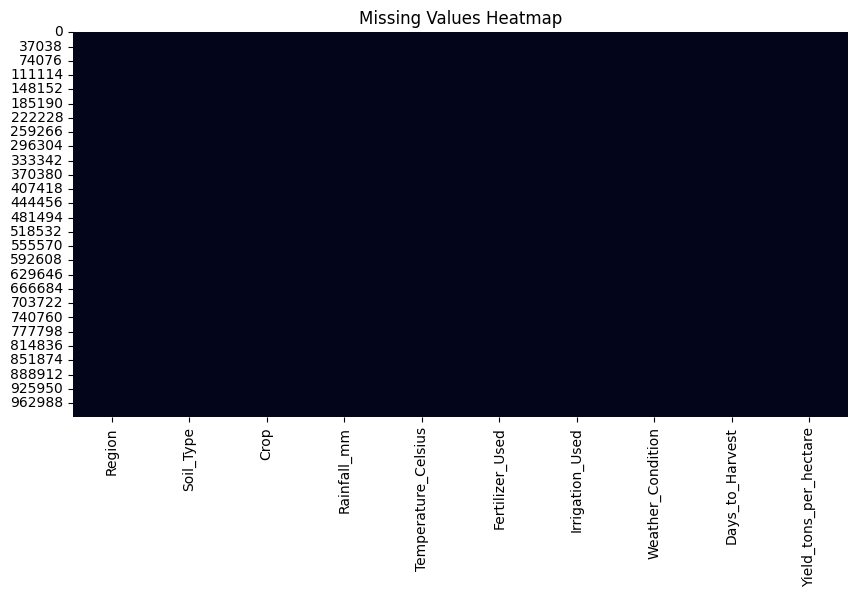

In [6]:
# =========================
# CHECK MISSING VALUES
# =========================

missing = df.isnull().sum()

print(missing)

# Visualize missing values
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [7]:
# =========================
# STATISTICAL SUMMARY
# =========================

df.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


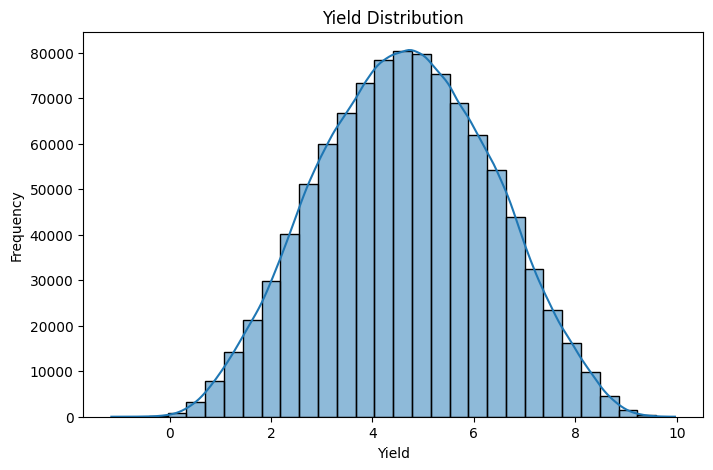

In [8]:
# =========================
# TARGET DISTRIBUTION
# =========================

plt.figure(figsize=(8,5))

sns.histplot(df['Yield_tons_per_hectare'], bins=30, kde=True)

plt.title("Yield Distribution")
plt.xlabel("Yield")
plt.ylabel("Frequency")

plt.show()

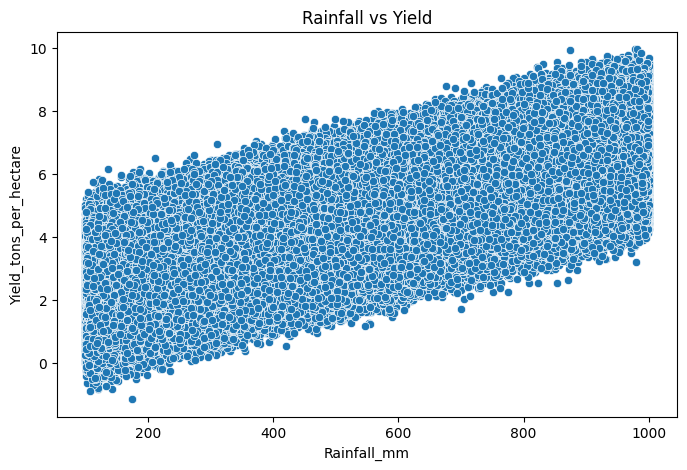

In [9]:
# =========================
# RAINFALL VS YIELD
# =========================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Rainfall_mm'],
    y=df['Yield_tons_per_hectare']
)

plt.title("Rainfall vs Yield")

plt.show()

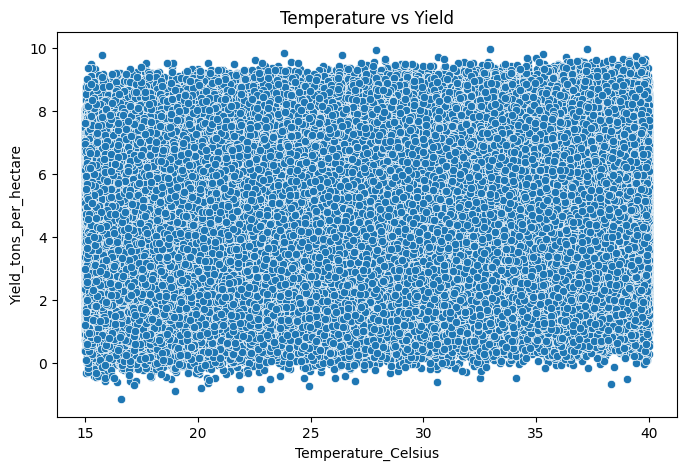

In [10]:
# =========================
# TEMPERATURE VS YIELD
# =========================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Temperature_Celsius'],
    y=df['Yield_tons_per_hectare']
)

plt.title("Temperature vs Yield")

plt.show()

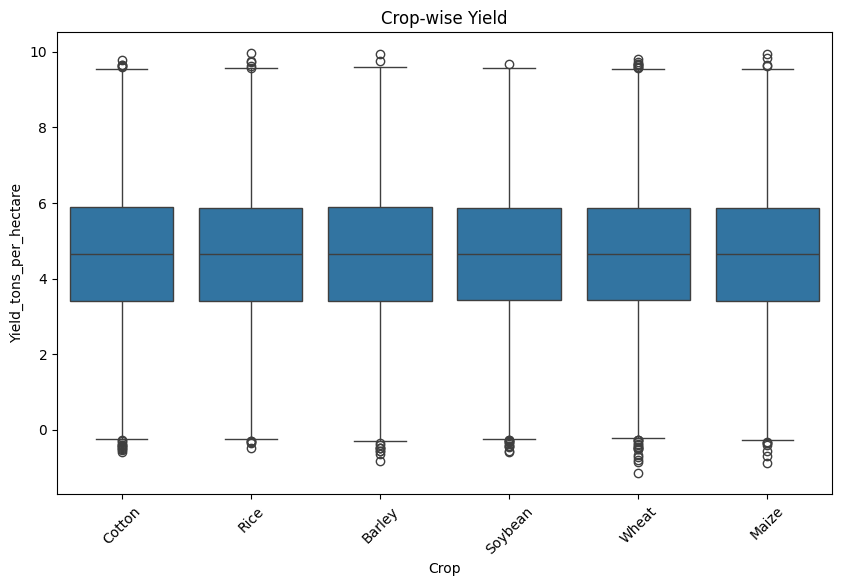

In [11]:
# =========================
# CROP-WISE YIELD
# =========================

plt.figure(figsize=(10,6))

sns.boxplot(
    x='Crop',
    y='Yield_tons_per_hectare',
    data=df
)

plt.xticks(rotation=45)

plt.title("Crop-wise Yield")

plt.show()

In [12]:
# =========================
# FEATURE ENGINEERING
# =========================

# Convert boolean columns to integer
df['Fertilizer_Used'] = df['Fertilizer_Used'].astype(int)
df['Irrigation_Used'] = df['Irrigation_Used'].astype(int)

df.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,0,1,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,1,1,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,0,0,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,0,1,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,1,1,Cloudy,110,7.248251


In [13]:
# =========================
# FEATURES & TARGET
# =========================

X = df.drop('Yield_tons_per_hectare', axis=1)

y = df['Yield_tons_per_hectare']

print(X.shape)
print(y.shape)

(1000000, 9)
(1000000,)


In [14]:
# =========================
# COLUMN TYPES
# =========================

categorical_cols = [
    'Region',
    'Soil_Type',
    'Crop',
    'Weather_Condition'
]

numerical_cols = [
    'Rainfall_mm',
    'Temperature_Celsius',
    'Fertilizer_Used',
    'Irrigation_Used',
    'Days_to_Harvest'
]

print("Categorical Columns:", categorical_cols)
print("Numerical Columns:", numerical_cols)

Categorical Columns: ['Region', 'Soil_Type', 'Crop', 'Weather_Condition']
Numerical Columns: ['Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Days_to_Harvest']


In [15]:
# =========================
# PREPROCESSING
# =========================

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

In [16]:
# =========================
# TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(800000, 9)
(200000, 9)


In [17]:
# =========================
# LINEAR REGRESSION
# =========================

lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression Results")
print("MAE :", mean_absolute_error(y_test, lr_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_pred)))
print("R2  :", r2_score(y_test, lr_pred))

Linear Regression Results
MAE : 0.3995540808713492
RMSE: 0.5007760662930835
R2  : 0.9130137709140372


In [18]:
# =========================
# RANDOM FOREST
# =========================

rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Results")
print("MAE :", mean_absolute_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2  :", r2_score(y_test, rf_pred))

Random Forest Results
MAE : 0.41143734019493156
RMSE: 0.5156984045111636
R2  : 0.9077524265224629


In [19]:
# =========================
# GRADIENT BOOSTING
# =========================

gb_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', GradientBoostingRegressor(
        random_state=42
    ))
])

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_test)

print("Gradient Boosting Results")
print("MAE :", mean_absolute_error(y_test, gb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, gb_pred)))
print("R2  :", r2_score(y_test, gb_pred))

Gradient Boosting Results
MAE : 0.400859315106318
RMSE: 0.5023792299804302
R2  : 0.9124559312209971


In [20]:
# =========================
# MODEL COMPARISON
# =========================

results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE': [
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, gb_pred)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, gb_pred))
    ],
    'R2 Score': [
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.399554,0.500776,0.913014
1,Random Forest,0.411437,0.515698,0.907752
2,Gradient Boosting,0.400859,0.502379,0.912456


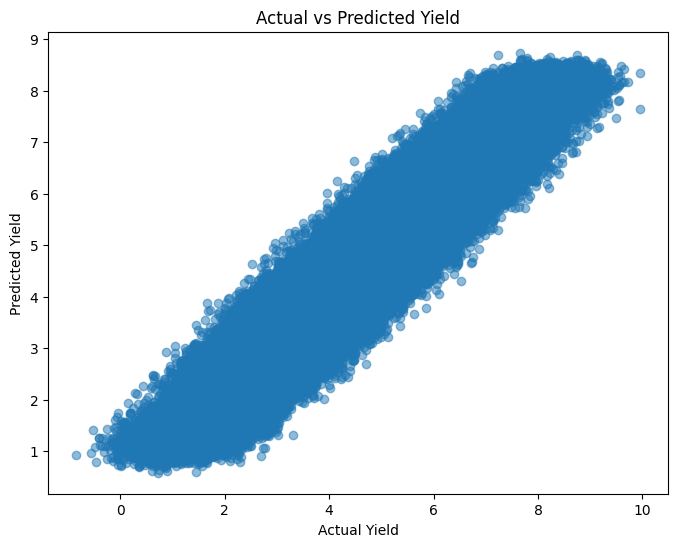

In [21]:
# =========================
# ACTUAL VS PREDICTED
# =========================

plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_pred, alpha=0.5)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")

plt.title("Actual vs Predicted Yield")

plt.show()

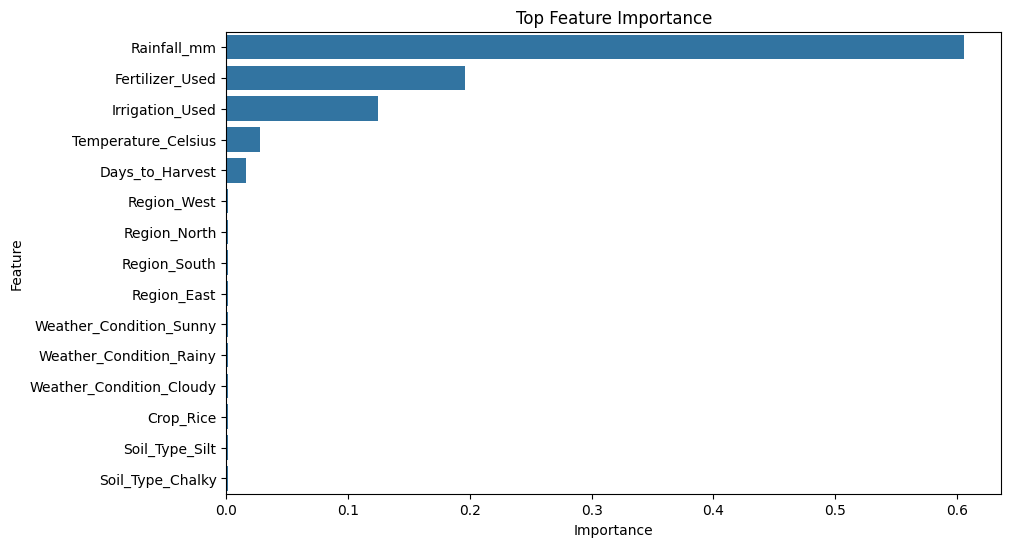

In [22]:
# =========================
# FEATURE IMPORTANCE
# =========================

# Train standalone RF for feature importance

X_encoded = pd.get_dummies(X)

X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_enc, y_train_enc)

importance = pd.DataFrame({
    'Feature': X_encoded.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

# Top 15 Features
top_features = importance.head(15)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top Feature Importance")

plt.show()

In [23]:
# =========================
# SAVE MODEL
# =========================

import joblib

joblib.dump(rf_model, 'crop_yield_model.pkl')

print("Model Saved Successfully!")

Model Saved Successfully!


In [24]:
# =========================
# SAMPLE PREDICTION
# =========================

sample = pd.DataFrame({
    'Region': ['North'],
    'Soil_Type': ['Loam'],
    'Crop': ['Wheat'],
    'Rainfall_mm': [500],
    'Temperature_Celsius': [25],
    'Fertilizer_Used': [1],
    'Irrigation_Used': [1],
    'Weather_Condition': ['Sunny'],
    'Days_to_Harvest': [120]
})

prediction = rf_model.predict(sample)

print("Predicted Yield:", prediction[0])

Predicted Yield: 5.661556169404752
